# ViT

In [ ]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets

def subset_sampler(dataset, classes, max_len):
  target_idx = defaultdict(list)
  for idx, label in enumerate(dataset.train_labels):
    target_idx[int(label)].append(idx)

  indices = list(
      chain.from_iterable(
          [target_idx[idx][:max_len] for idx in range(len(classes))]
      )
  )
  return Subset(dataset, indices)

train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download = True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print(classes)
print(class_to_idx)

subset_train_dataset = subset_sampler(
    dataset = train_dataset, classes = train_dataset.classes, max_len = 1000
) #subsampling 수행 -> dataset, 클래스 목록, 클래스별 최대 샘플링 개수 전달
subset_test_dataset = subset_sampler(
    dataset = test_dataset, classes=test_dataset.classes, max_len = 100
)

print(f"Training Data Size : {len(subset_train_dataset)}")
print(f"Testing Data Size : {len(subset_test_dataset)}")
print(train_dataset[0])

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.14MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Training Data Size : 10000
Testing Data Size : 1000
(<PIL.Image.Image image mode=L size=28x28 at 0x7D1F7CFCAF00>, 9)


In [ ]:
# 이미지 전처리
import torch
from torchvision import transforms
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path = "google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size = (
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x,x,x],0)
        ),
        transforms.Normalize(
            mean = image_processor.image_mean,
            std = image_processor.image_std
        )
    ]
)

print(f"size: {image_processor.size}")
print(f"mean:{image_processor.image_mean}")
print(f"std: {image_processor.image_std}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


size: {'height': 224, 'width': 224}
mean:[0.5, 0.5, 0.5]
std: [0.5, 0.5, 0.5]


In [ ]:
from torch.utils.data import DataLoader

def collator(data, transform):# 사용자 정의 함수 생성
  images, labels = zip(*data)
  pixels_values = torch.stack([transform(image) for image in images])
  labels = torch.tensor([label for label in labels])
  return {"pixel_values":pixels_values, "labels":labels}

train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size = 32,
    shuffle=True,
    collate_fn = lambda x:collator(x, transform),
    drop_last = True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size = 4,
    shuffle=True,
    collate_fn = lambda x:collator(x,transform),
    drop_last = True
)

batch = next(iter(train_dataloader))
for key, value in batch.items():
  print(f"{key}:{value.shape}")

pixel_values:torch.Size([32, 3, 224, 224])
labels:torch.Size([32])


In [ ]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    pretrained_model_name_or_path = "google/vit-base-patch16-224-in21k",
    num_labels = len(classes), #미세조정
    id2label = {idx: label for label,idx in class_to_idx.items()},
    label2id = class_to_idx,
    ignore_mismatched_sizes=True
)
print(model.classifier)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Linear(in_features=768, out_features=10, bias=True)


In [ ]:
print(model.vit.embeddings)

batch = next(iter(train_dataloader))
print("image shape:", batch["pixel_values"].shape)
print("patch embeddings shape:",
      model.vit.embeddings.patch_embeddings(batch["pixel_values"]).shape
)
print("[CLS] + patch embeddings shape:",
      model.vit.embeddings(batch["pixel_values"]).shape)

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
image shape: torch.Size([32, 3, 224, 224])
patch embeddings shape: torch.Size([32, 196, 768])
[CLS] + patch embeddings shape: torch.Size([32, 197, 768])


In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir = "../models/ViT-FashionMNIST",
    save_strategy = "epoch",
    eval_strategy = "epoch",
    learning_rate = 1e-5,
    per_device_train_batch_size =16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 3,
    weight_decay = 0.001,
    load_best_model_at_end = True,
    metric_for_best_model = "f1",
    logging_dir = "logs",
    logging_steps = 125,
    remove_unused_columns = False,
    seed = 7
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.8 MB/s eta 0:00:00


In [ ]:
import evaluate
import numpy as np

def compute_metris(eval_pred):
  metric = evaluate.load("f1")
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis = 1)
  macro_f1 = metric.compute(
      predictions= predictions, references = labels, average = "macro"
  )
  return macro_f1

In [ ]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer

def subset_sampler(dataset, classes, max_len):
  target_idx = defaultdict(list)
  for idx, label in enumerate(dataset.targets):
    target_idx[int(label)].append(idx)

  indices = list(
      chain.from_iterable(
          [target_idx[idx][:max_len] for idx in range(len(classes))]
      )
  )
  return Subset(dataset, indices)

def model_init(classes, class_to_idx):
  model = ViTForImageClassification.from_pretrained(
      pretrained_model_name_or_path = "google/vit-base-patch16-224-in21k",
      num_labels = len(classes),
      id2label = {idx:label for label, idx in class_to_idx.items()},
      label2id = class_to_idx,
  )
  return model

def collator(data, transform):
  images, labels = zip(*data)
  pixel_values = torch.stack([transform(image) for image in images])
  labels = torch.tensor([label for label in labels])
  return {"pixel_values": pixel_values, "labels":labels}

def compute_metrics(eval_pred):
  metric= evaluate.load("f1")
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis = 1)
  macro_f1 = metric.compute(
      predictions = predictions, references = labels, average = "macro"
  )
  return macro_f1

train_dataset = datasets.FashionMNIST(root = "../datasets", download = True, train=True)
test_dataset = datasets.FashionMNIST(root = "../datasets", download = True, train = False)

classes = train_dataset.classes
class_to_idx =train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset = test_dataset, classes = test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path = "google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size = (
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x,x,x], 0)
        ),
        transforms.Normalize(
            mean = image_processor.image_mean,
            std = image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir = "../models/ViT-FashionMNIST",
    save_strategy = "epoch",
    eval_strategy = "epoch",
    learning_rate = 1e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 3,
    weight_decay = 0.001,
    load_best_model_at_end = True,
    metric_for_best_model = "f1",
    logging_dir = "logs",
    logging_steps = 125,
    remove_unused_columns = False,
    seed = 7
)

trainer = Trainer(
    model_init = lambda x: model_init(classes, class_to_idx),
    args = args,
    train_dataset = subset_train_dataset,
    eval_dataset = subset_test_dataset,
    data_collator = lambda x: collator(x, transform),
    compute_metrics = compute_metrics,
    #tokenizer = image_processor,
)
trainer.train()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1
1,0.695471,0.633122,0.892783
2,0.464749,0.464143,0.924781
3,0.404471,0.419417,0.925552


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.6900211059570313, metrics={'train_runtime': 1217.613, 'train_samples_per_second': 24.638, 'train_steps_per_second': 1.54, 'total_flos': 2.32492637712384e+18, 'train_loss': 0.6900211059570313, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 3.094167  , -0.55052346, -0.3013338 , ..., -0.5706589 ,
        -0.46123824, -0.56790406],
       [ 1.8424574 , -0.50546825,  0.16514508, ..., -0.6748731 ,
        -0.6733362 , -0.9425242 ],
       [ 3.0610178 , -0.5857136 , -0.245788  , ..., -0.5949338 ,
        -0.3748346 , -0.5283108 ],
       ...,
       [-0.60695654, -0.6398731 , -0.5765279 , ...,  0.38914305,
         0.13116226,  2.9944756 ],
       [-0.4290285 , -0.5689926 , -0.43692294, ...,  0.17153373,
        -0.3607581 ,  3.3340423 ],
       [-0.32417598, -0.5931944 , -0.3782695 , ..., -0.28288278,
        -0.2872149 ,  3.3125274 ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

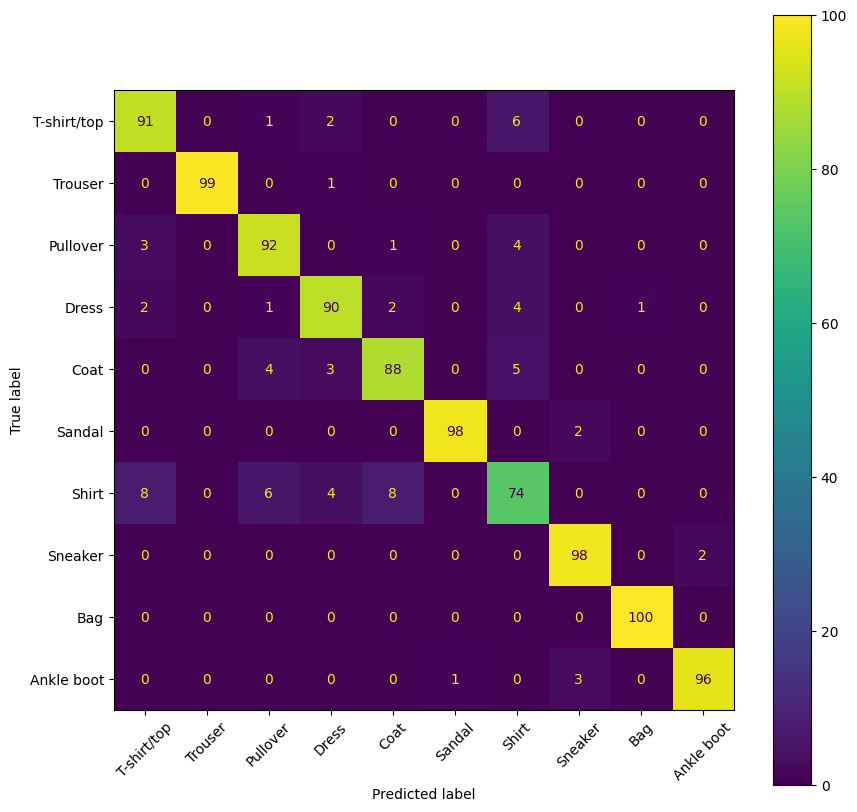

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = labels)
_, ax = plt.subplots(figsize =(10,10))
display.plot(xticks_rotation = 45, ax = ax)
plt.show()

# Swin transformer

상대적 위치 편향 계산

In [ ]:
import torch

window_size = 2
coords_h = torch.arange(window_size)
coords_w = torch.arange(window_size)
coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing = "ij"))
coords_flatten = torch.flatten(coords, 1)
relative_coords = coords_flatten[:, :, None] -coords_flatten[:, None, :]

print(relative_coords)
print(relative_coords.shape)

tensor([[[ 0,  0, -1, -1],
         [ 0,  0, -1, -1],
         [ 1,  1,  0,  0],
         [ 1,  1,  0,  0]],

        [[ 0, -1,  0, -1],
         [ 1,  0,  1,  0],
         [ 0, -1,  0, -1],
         [ 1,  0,  1,  0]]])
torch.Size([2, 4, 4])


In [ ]:
x_coords = relative_coords[0,:,:]
y_coords = relative_coords[1,:,:]

x_coords += window_size - 1
y_coords += window_size - 1
x_coords *= 2*window_size -1

print(f'X축에 대한 행렬:\n{x_coords}\n')
print(f'Y축에 대한 행렬:\n{y_coords}\n')

relative_position_index = x_coords+y_coords
print(f"X,Y축에 대한 위치 행렬:\n{relative_position_index}")

X축에 대한 행렬:
tensor([[3, 3, 0, 0],
        [3, 3, 0, 0],
        [6, 6, 3, 3],
        [6, 6, 3, 3]])

Y축에 대한 행렬:
tensor([[1, 0, 1, 0],
        [2, 1, 2, 1],
        [1, 0, 1, 0],
        [2, 1, 2, 1]])

X,Y축에 대한 위치 행렬:
tensor([[4, 3, 1, 0],
        [5, 4, 2, 1],
        [7, 6, 4, 3],
        [8, 7, 5, 4]])


In [ ]:
num_heads = 1
relative_position_bias_table = torch.zeros(
    (2*window_size -1)*(2*window_size-1), num_heads
)

relative_position_bias = relative_position_bias_table[relative_position_index.view(-1)]
relative_position_bias = relative_position_bias.view(
    window_size* window_size, window_size*window_size, num_heads
)
print(relative_position_bias.shape)

torch.Size([4, 4, 1])


모델 실습

In [ ]:
from transformers import SwinForImageClassification

model = SwinForImageClassification.from_pretrained(
    pretrained_model_name_or_path = "microsoft/swin-tiny-patch4-window7-224",
    num_labels = len(train_dataset.classes),
    id2label = {idx:label for label, idx in train_dataset.class_to_idx.items()},
    label2id = train_dataset.class_to_idx,
    ignore_mismatched_sizes = True
)

for main_name, main_module in model.named_children():
  print(main_name)
  for sub_name, sub_module in main_module.named_children():
    print("└", sub_name)
    for ssub_name, ssub_module in sub_module.named_children():
      print("│ └", ssub_name)
      for sssub_name, sssub_module in ssub_module.named_children():
        if sssub_name == "projection":
          print("│ │ └", sssub_name, sssub_module)
        else:
          print("│ │ └", sssub_name)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


swin
└ embeddings
│ └ patch_embeddings
│ │ └ projection Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
│ └ norm
│ └ dropout
└ encoder
│ └ layers
│ │ └ 0
│ │ └ 1
│ │ └ 2
│ │ └ 3
└ layernorm
└ pooler
classifier


In [ ]:
batch = next(iter(train_dataloader))
print("이미지 차원:", batch["pixel_values"].shape)

patch_emb_output = model.swin.embeddings.patch_embeddings(batch["pixel_values"])
print("모듈:", model.swin.embeddings.patch_embeddings)
print("패치 임베딩 차원:", patch_emb_output[0].shape)

이미지 차원: torch.Size([32, 3, 224, 224])
모듈: SwinPatchEmbeddings(
  (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
)
패치 임베딩 차원: torch.Size([32, 3136, 96])


In [ ]:
for main_name, main_module in model.swin.encoder.layers[0].named_children():
  print(main_name)
  for sub_name, sub_module in main_module.named_children():
     print("└", sub_name)
     for ssub_name, ssub_module in sub_module.named_children():
      print("│ └", ssub_name)

blocks
└ 0
│ └ layernorm_before
│ └ attention
│ └ drop_path
│ └ layernorm_after
│ └ intermediate
│ └ output
└ 1
│ └ layernorm_before
│ └ attention
│ └ drop_path
│ └ layernorm_after
│ └ intermediate
│ └ output
downsample
└ reduction
└ norm


In [ ]:
#SwinLayer 구조
print(model.swin.encoder.layers[0].blocks[0])

SwinLayer(
  (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (attention): SwinAttention(
    (self): SwinSelfAttention(
      (query): Linear(in_features=96, out_features=96, bias=True)
      (key): Linear(in_features=96, out_features=96, bias=True)
      (value): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (output): SwinSelfOutput(
      (dense): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (drop_path): Identity()
  (layernorm_after): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (intermediate): SwinIntermediate(
    (dense): Linear(in_features=96, out_features=384, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): SwinOutput(
    (dense): Linear(in_features=384, out_features=96, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)


In [ ]:
hidden_states_tensor, current_resolution = patch_emb_output

print("패치 임베딩 차원:", hidden_states_tensor.shape)

W_MSA = model.swin.encoder.layers[0].blocks[0]
SW_MSA = model.swin.encoder.layers[0].blocks[1]

w_msa_output_tuple = W_MSA(hidden_states_tensor, current_resolution)
w_msa_output_tensor = w_msa_output_tuple[0]

sw_msa_output_tuple = SW_MSA(w_msa_output_tensor, current_resolution)
sw_msa_output_tensor = sw_msa_output_tuple[0]

print("W-MSA 차원:", w_msa_output_tensor.shape)
print("SW-MSA 차원:", sw_msa_output_tensor.shape)

패치 임베딩 차원: torch.Size([32, 3136, 96])
W-MSA 차원: torch.Size([32, 3136, 96])
SW-MSA 차원: torch.Size([32, 3136, 96])


In [ ]:
import torch

patch_merge = model.swin.encoder.layers[0].downsample
print("patch_merge 모듈:", patch_merge)

output = patch_merge(sw_msa_output_tensor, patch_merge.input_resolution)
print("patch_merge 결과 차원:", output.shape)

patch_merge 모듈: SwinPatchMerging(
  (reduction): Linear(in_features=384, out_features=192, bias=False)
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)
patch_merge 결과 차원: torch.Size([32, 784, 192])


In [ ]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer
from transformers import SwinForImageClassification

def subset_sampler(dataset, classes, max_len):
  target_idx = defaultdict(list)
  for idx, label in enumerate(dataset.targets):
    target_idx[int(label)].append(idx)

  indices = list(
      chain.from_iterable(
          [target_idx[idx][:max_len] for idx in range(len(classes))]
      )
  )
  return Subset(dataset, indices)

def model_init(classes, class_to_idx):
  model = SwinForImageClassification.from_pretrained(
      pretrained_model_name_or_path = "microsoft/swin-tiny-patch4-window7-224",
      num_labels = len(classes),
      id2label = {idx:label for label, idx in class_to_idx.items()},
      label2id = class_to_idx,
      ignore_mismatched_sizes = True
  )
  return model

def collator(data, transform):
  images, labels = zip(*data)
  pixel_values = torch.stack([transform(image) for image in images])
  labels = torch.tensor([label for label in labels])
  return {"pixel_values": pixel_values, "labels":labels}

def compute_metrics(eval_pred):
  metric= evaluate.load("f1")
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis = 1)
  macro_f1 = metric.compute(
      predictions = predictions, references = labels, average = "macro"
  )
  return macro_f1

train_dataset = datasets.FashionMNIST(root = "../datasets", download = True, train=True)
test_dataset = datasets.FashionMNIST(root = "../datasets", download = True, train = False)

classes = train_dataset.classes
class_to_idx =train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=500
)
subset_test_dataset = subset_sampler(
    dataset = test_dataset, classes = test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path = "microsoft/swin-tiny-patch4-window7-224"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size = (
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x,x,x], 0)
        ),
        transforms.Normalize(
            mean = image_processor.image_mean,
            std = image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir = "../models/Swin-FashionMNIST",
    save_strategy = "epoch",
    eval_strategy = "epoch",
    learning_rate = 1e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 3,
    weight_decay = 0.001,
    load_best_model_at_end = True,
    metric_for_best_model = "f1",
    logging_dir = "logs",
    logging_steps = 125,
    remove_unused_columns = False,
    seed = 7
)

trainer = Trainer(
    model_init = lambda x: model_init(classes, class_to_idx),
    args = args,
    train_dataset = subset_train_dataset,
    eval_dataset = subset_test_dataset,
    data_collator = lambda x: collator(x, transform),
    compute_metrics = compute_metrics,
    #tokenizer = image_processor,
)
trainer.train()

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,F1
1,0.341954,0.299218,0.888883
2,0.245917,0.251316,0.910205
3,0.214951,0.227505,0.924101


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.3612107645670573, metrics={'train_runtime': 517.895, 'train_samples_per_second': 57.927, 'train_steps_per_second': 3.62, 'total_flos': 7.4584635826176e+17, 'train_loss': 0.3612107645670573, 'epoch': 3.0})

# CvT

In [ ]:
import torch
from torchvision import transforms
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path = "microsoft/cvt-21"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size = (
                image_processor.size["shortest_edge"],
                image_processor.size["shortest_edge"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x,x,x],0)
        ),
        transforms.Normalize(
            mean = image_processor.image_mean,
            std = image_processor.image_std
        )
    ]
)

print(f"size: {image_processor.size}")
print(f"mean:{image_processor.image_mean}")
print(f"std: {image_processor.image_std}")

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


size: {'shortest_edge': 224}
mean:[0.485, 0.456, 0.406]
std: [0.229, 0.224, 0.225]


In [ ]:
from torch.utils.data import DataLoader

def collator(data, transform):
  images, labels = zip(*data)
  pixels_values = torch.stack([transform(image) for image in images])
  labels = torch.tensor([label for label in labels])
  return {"pixel_values":pixels_values, "labels":labels}

train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size = 32,
    shuffle=True,
    collate_fn = lambda x:collator(x, transform),
    drop_last = True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size = 4,
    shuffle=True,
    collate_fn = lambda x:collator(x,transform),
    drop_last = True
)

batch = next(iter(train_dataloader))
for key, value in batch.items():
  print(f"{key}:{value.shape}")

pixel_values:torch.Size([32, 3, 224, 224])
labels:torch.Size([32])


In [ ]:
from transformers import CvtForImageClassification

model = CvtForImageClassification.from_pretrained(
    pretrained_model_name_or_path = "microsoft/cvt-21",
    num_labels = len(train_dataset.classes),
    id2label = {idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id = train_dataset.class_to_idx,
    ignore_mismatched_sizes = True
)
for main_name, main_module in model.named_children():
  print(main_name)
  for sub_name, sub_module in main_module.named_children():
    print("└", sub_name)
    for ssub_name, ssub_module in sub_module.named_children():
      print("  └", ssub_name)
      for sssub_name, sssub_name in ssub_module.named_children():
          print("    └", sssub_name, sssub_module)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/127M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/731 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-21
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([10, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


cvt
└ encoder
  └ stages
    └ CvtStage(
  (embedding): CvtEmbeddings(
    (convolution_embeddings): CvtConvEmbeddings(
      (projection): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
      (normalization): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (layers): Sequential(
    (0): CvtLayer(
      (attention): CvtAttention(
        (attention): CvtSelfAttention(
          (convolution_projection_query): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAttentionConvProjection(
              (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (linear_projection): CvtSelfAttentionLinearProjection()
          )
          (convolution_projection_key): CvtSelfAttentionProjection(
            (convo

In [ ]:
stages = model.cvt.encoder.stages
print(stages[0])

CvtStage(
  (embedding): CvtEmbeddings(
    (convolution_embeddings): CvtConvEmbeddings(
      (projection): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
      (normalization): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (layers): Sequential(
    (0): CvtLayer(
      (attention): CvtAttention(
        (attention): CvtSelfAttention(
          (convolution_projection_query): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAttentionConvProjection(
              (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (linear_projection): CvtSelfAttentionLinearProjection()
          )
          (convolution_projection_key): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAtte

In [ ]:
batch = next(iter(train_dataloader))
print("이미지 차원:", batch["pixel_values"].shape)

patch_emb_output = stages[0].embedding(batch["pixel_values"])
print("패치 임베딩 차원:", patch_emb_output.shape)

batch_size, num_channels, height, width = patch_emb_output.shape
hidden_state = patch_emb_output.view(batch_size, num_channels, height*width).permute(0,2,1)
print("셀프 어텐션 입력 차원:", hidden_state.shape)

attention_output  = stages[0].layers[0].attention.attention(hidden_state, height, width)
print("셀프 어텐션 출력 차원:", attention_output.shape)

이미지 차원: torch.Size([32, 3, 224, 224])
패치 임베딩 차원: torch.Size([32, 64, 56, 56])
셀프 어텐션 입력 차원: torch.Size([32, 3136, 64])


model.safetensors:   0%|          | 0.00/127M [00:00<?, ?B/s]

셀프 어텐션 출력 차원: torch.Size([32, 3136, 64])


In [ ]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer
from transformers import CvtForImageClassification

def subset_sampler(dataset, classes, max_len):
  target_idx = defaultdict(list)
  for idx, label in enumerate(dataset.targets):
    target_idx[int(label)].append(idx)

  indices = list(
      chain.from_iterable(
          [target_idx[idx][:max_len] for idx in range(len(classes))]
      )
  )
  return Subset(dataset, indices)

def model_init(classes, class_to_idx):
  model = CvtForImageClassification.from_pretrained(
      pretrained_model_name_or_path = "microsoft/cvt-21",
      num_labels = len(classes),
      id2label = {idx:label for label, idx in class_to_idx.items()},
      label2id = class_to_idx,
      ignore_mismatched_sizes=True
  )
  return model

def collator(data, transform):
  images, labels = zip(*data)
  pixel_values = torch.stack([transform(image) for image in images])
  labels = torch.tensor([label for label in labels])
  return {"pixel_values": pixel_values, "labels":labels}

def compute_metrics(eval_pred):
  metric= evaluate.load("f1")
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis = 1)
  macro_f1 = metric.compute(
      predictions = predictions, references = labels, average = "macro"
  )
  return macro_f1

train_dataset = datasets.FashionMNIST(root = "../datasets", download = True, train=True)
test_dataset = datasets.FashionMNIST(root = "../datasets", download = True, train = False)

classes = train_dataset.classes
class_to_idx =train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=100
)
subset_test_dataset = subset_sampler(
    dataset = test_dataset, classes = test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path = "microsoft/cvt-21"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size = (
                image_processor.size["shortest_edge"],
                image_processor.size["shortest_edge"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x,x,x], 0)
        ),
        transforms.Normalize(
            mean = image_processor.image_mean,
            std = image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir = "../models/CvT-FashionMNIST",
    save_strategy = "epoch",
    eval_strategy = "epoch",
    learning_rate = 1e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 3,
    weight_decay = 0.001,
    load_best_model_at_end = True,
    metric_for_best_model = "f1",
    logging_dir = "logs",
    logging_steps = 125,
    remove_unused_columns = False,
    seed = 7
)

trainer = Trainer(
    model_init = lambda x: model_init(classes, class_to_idx),
    args = args,
    train_dataset = subset_train_dataset,
    eval_dataset = subset_test_dataset,
    data_collator = lambda x: collator(x, transform),
    compute_metrics = compute_metrics,
    #tokenizer = image_processor,
)
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Loading weights:   0%|          | 0/731 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-21
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([10, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading weights:   0%|          | 0/731 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-21
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([10, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,F1
1,No log,1.189338,0.662969
2,1.583180,0.878542,0.736094
3,1.583180,0.770151,0.771336


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]